# Classifying text into 6 emotions (sadness, joy, love, anger, fear, surprise) by comparing plain recurrent models before building an Advanced Bidirectional GRU.

1. Import Libraries

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset


2. Load Dataset

Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [10]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']


In [11]:
label_names = emotion_dataset['train'].features['label'].names


In [12]:
label_names


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [13]:

df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [14]:
df_train.isnull().sum()


,0
text,0
label,0


3. Exploratory Data Analysis (EDA)

Visualize class distribution across the 6 emotion labels.

In [15]:
df_train['label'].value_counts().index


Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

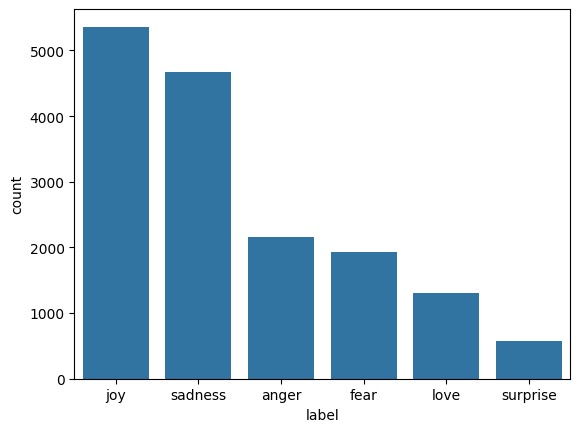

In [16]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)


In [17]:
df_train


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


4. Data Preprocessing - Using NLP

Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


5. Shared Training Utilities

Compute balanced class weights to handle dataset skew and setup early stopping.

In [19]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [20]:

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

6. Phase 1 — Plain Foundational Models

Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

6.1 Model 1 — Simple RNN

Plain unrolled Recurrent Neural Network.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [22]:

rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step - accuracy: 0.1626 - loss: 1.9693 - val_accuracy: 0.1615 - val_loss: 1.7708
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.1652 - loss: 1.8102 - val_accuracy: 0.1315 - val_loss: 1.7868
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1621 - loss: 1.7885 - val_accuracy: 0.1155 - val_loss: 1.8211
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.1531 - loss: 1.7748 - val_accuracy: 0.0620 - val_loss: 1.8233
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1615 - loss: 1.7708
RNN Loss: 1.7707645893096924
RNN Accuracy: 0.1615000069141388


6.2 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [23]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 74s 140ms/step - accuracy: 0.1417 - loss: 1.7948 - val_accuracy: 0.1150 - val_loss: 1.8042
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 129ms/step - accuracy: 0.1468 - loss: 1.7964 - val_accuracy: 0.1345 - val_loss: 1.7837
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 129ms/step - accuracy: 0.1552 - loss: 1.7932 - val_accuracy: 0.1100 - val_loss: 1.8105
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.1150 - loss: 1.8042
LSTM Loss: 1.8042054176330566
LSTM Accuracy: 0.11500000208616257


6.3 Model 3 — Standard GRU
Plain stacked Gated Recurrent Unit network.

In [24]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 113ms/step - accuracy: 0.1467 - loss: 1.7968 - val_accuracy: 0.2895 - val_loss: 1.7991
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.1400 - loss: 1.7944 - val_accuracy: 0.3450 - val_loss: 1.7707
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.1641 - loss: 1.7949 - val_accuracy: 0.2845 - val_loss: 1.7954
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 114ms/step - accuracy: 0.1388 - loss: 1.7933 - val_accuracy: 0.0355 - val_loss: 1.7909
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.1713 - loss: 1.7913 - val_accuracy: 0.0850 - val_loss: 1.8275
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3450 - loss: 1.7707
GRU Loss: 1.77065908908844
GRU Accuracy: 0.3449999988079071



6.4 Phase 1 Ranking & Selection
Rank foundational models to pick the best base cell for Phase 2.

In [25]:


result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
2,GRU,1.770659,0.3450
0,RNN,1.770765,0.1615
1,LSTM,1.804205,0.1150


7. Phase 2 — Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [26]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train & Evaluate Advanced Bidirectional GRU

In [27]:

BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 160s 307ms/step - accuracy: 0.5840 - loss: 1.0593 - val_accuracy: 0.8805 - val_loss: 0.3908
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 152s 305ms/step - accuracy: 0.9127 - loss: 0.2524 - val_accuracy: 0.9075 - val_loss: 0.2407
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 158s 317ms/step - accuracy: 0.9444 - loss: 0.1503 - val_accuracy: 0.9185 - val_loss: 0.2300
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 151s 302ms/step - accuracy: 0.9577 - loss: 0.1126 - val_accuracy: 0.9165 - val_loss: 0.2470
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 152s 303ms/step - accuracy: 0.9671 - loss: 0.0875 - val_accuracy: 0.9115 - val_loss: 0.3445
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 314ms/step - accuracy: 0.9745 - loss: 0.0763 - val_accuracy: 0.9195 - val_loss: 0.2667


In [28]:

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9185 - loss: 0.2300
BiGRU Loss: 0.23003102838993073
BiGRU Accuracy: 0.9185000061988831


8. Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

In [29]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step


<Axes: >

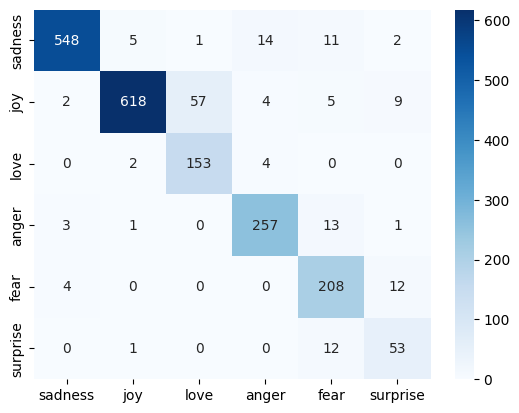

In [30]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

9. Final Predictions
Test the winning model on unseen sample sentences.

In [31]:


sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


10. Save Model & Tokenizer
Export trained model and tokenizer artifacts for API deployment.

In [32]:

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)